<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 2: Clustering por Gaussian Mixture Models</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clustering basado en GMM. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales: leea y responda los siguientes incisos</b>
<ul>
</ul>
</div>

**1.** Utilice GMM para la segmentación de clientes en el análisis de la cesta de la compra del siguiente dataset `customer_shopping.csv`. Emplee GMM para agrupar a los clientes según su comportamiento de compra. Una vez agrupados, podrá crear promociones dirigidas y recomendaciones personalizadas para cada segmento.

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns; sns.set()
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#Cargamos el dataset
df = pd.read_csv('./data/customer_shopping.csv')

In [2]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Customer  84 non-null     object
 1   Bread     84 non-null     int64 
 2   Milk      84 non-null     int64 
 3   Eggs      84 non-null     int64 
 4   Beer      84 non-null     int64 
 5   Chips     84 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 4.1+ KB


,Customer,Bread,Milk,Eggs,Beer,Chips
0,c001,12,10,8,0,1
1,c002,10,8,7,1,0
2,c003,11,9,6,0,1
3,c004,1,2,1,10,8
4,c005,0,1,2,12,10


In [3]:
# Escalamiento y selección de características, utilice las columnas 'Bread', 'Milk', 'Eggs', 'Beer', 'Chips'

# Características que utilizaremos para el clustering
features_customer = ['Bread', 'Milk', 'Eggs', 'Beer', 'Chips']

# Verificamos que las columnas existan
missing_columns = [
    col for col in features_customer 
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Faltan las siguientes columnas en el dataset: {missing_columns}"
    )

# Seleccionamos las variables
X_customer = df[features_customer].copy()

# Tratamiento de valores faltantes
X_customer = X_customer.fillna(X_customer.median())

# Escalamiento
scaler_customer = StandardScaler()
X_customer_scaled = scaler_customer.fit_transform(X_customer)

print("Características utilizadas:")
print(features_customer)

print("\nDimensiones de X:")
print(X_customer.shape)

print("\nPrimeras filas después de escalar:")
display(
    pd.DataFrame(
        X_customer_scaled,
        columns=features_customer
    ).head()
)

Características utilizadas:
['Bread', 'Milk', 'Eggs', 'Beer', 'Chips']

Dimensiones de X:
(84, 5)

Primeras filas después de escalar:


,Bread,Milk,Eggs,Beer,Chips
0,1.152739,1.267831,1.255927,-1.162292,-0.938417
1,0.748438,0.728601,0.930316,-0.944363,-1.196866
2,0.950588,0.998216,0.604706,-1.162292,-0.938417
3,-1.070916,-0.889086,-1.023348,1.017006,0.870728
4,-1.273066,-1.158701,-0.697737,1.452865,1.387627


In [4]:
#seleccionar el numero de componentes

componentes = range(2, 11)

aic_scores = []
bic_scores = []
silhouette_scores = []



,Componentes,AIC,BIC,Silhouette
0,2,498.268595,597.932084,0.595050
1,3,429.024102,579.734744,0.591591
2,4,429.559710,631.317504,0.466103
3,5,400.483555,653.288502,0.298314
4,6,352.927508,656.779608,0.461434
5,7,413.496450,768.395703,0.231921
6,8,345.604127,751.550532,0.269423
7,9,282.480544,739.474102,0.205427
8,10,233.800423,741.841134,0.174908


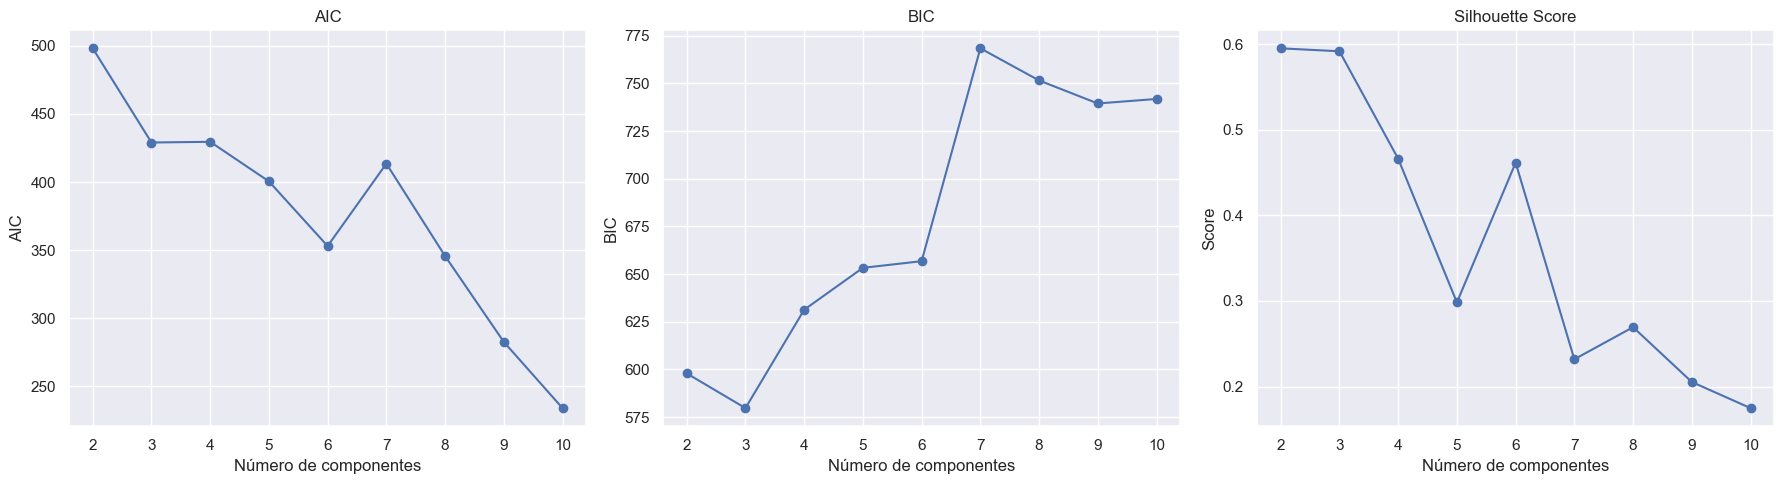

In [5]:
# Entrene el modelo por GMM utilice métricas para saber cuantos componentes elegir
for k in componentes:
    
    # Entrenamos GMM
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    
    labels = gmm.fit_predict(X_customer_scaled)
    
    # AIC y BIC
    aic_scores.append(gmm.aic(X_customer_scaled))
    bic_scores.append(gmm.bic(X_customer_scaled))
    
    # Silhouette
    silhouette_scores.append(
        silhouette_score(X_customer_scaled, labels)
    )

# Creamos tabla de resultados
metricas_customer = pd.DataFrame({    'Componentes': list(componentes),
    'AIC': aic_scores,
    'BIC': bic_scores,
    'Silhouette': silhouette_scores
})

display(metricas_customer)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AIC
axes[0].plot(
    metricas_customer['Componentes'],
    metricas_customer['AIC'],
    marker='o'
)

axes[0].set_title('AIC')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('AIC')
axes[0].grid(True)

# BIC
axes[1].plot(
    metricas_customer['Componentes'],
    metricas_customer['BIC'],
    marker='o'
)

axes[1].set_title('BIC')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('BIC')
axes[1].grid(True)

# Silhouette
axes[2].plot(
    metricas_customer['Componentes'],
    metricas_customer['Silhouette'],
    marker='o'
)

axes[2].set_title('Silhouette Score')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Seleccionamos el número de componentes con menor BIC
best_index = metricas_customer['BIC'].idxmin()

n_componentes_customer = int(metricas_customer.loc[best_index,'Componentes'])

print("Número de componentes seleccionado:",n_componentes_customer)

print("BIC correspondiente:",metricas_customer.loc[best_index, 'BIC'])

print("AIC correspondiente:",metricas_customer.loc[best_index,'AIC'    ])

print(
    "Silhouette correspondiente:",
    metricas_customer.loc[
        best_index,
        'Silhouette'
    ]
)

Número de componentes seleccionado: 3
BIC correspondiente: 579.7347437934515
AIC correspondiente: 429.02410226516605
Silhouette correspondiente: 0.5915911089113133


In [7]:
# Creamos el modelo GMM definitivo
gmm_customer = GaussianMixture(
    n_components=n_componentes_customer,    covariance_type='full',
    random_state=42,
    n_init=10
)

# Entrenamos y obtenemos el cluster de cada cliente
clusters_customer = gmm_customer.fit_predict(
    X_customer_scaled
)

# Agregamos el cluster al dataframe original
df['Cluster'] = clusters_customer

print("Modelo GMM entrenado correctamente.")
print("\nCantidad de clientes por cluster:")

print(
    df['Cluster']
    .value_counts()
    .sort_index()
)

Modelo GMM entrenado correctamente.

Cantidad de clientes por cluster:
Cluster
0    32
1    32
2    20
Name: count, dtype: int64


In [8]:
# Muestre el perfil de los clusters
perfil_clusters = df.groupby('Cluster')[
    features_customer
].mean()

print("Perfil promedio de los clientes por cluster:")
display(perfil_clusters.round(2))

Perfil promedio de los clientes por cluster:


,Bread,Milk,Eggs,Beer,Chips
Cluster,,,,,
0,12.06,9.34,7.41,0.78,0.84
1,1.34,1.41,0.94,10.66,9.03
2,5.00,5.05,4.05,4.10,3.65


In [9]:
# Número de clientes
cantidad_clusters = df['Cluster'].value_counts().sort_index()

# Porcentaje
porcentaje_clusters = (
    df['Cluster']
    .value_counts(normalize=True)
    .sort_index() * 100
)

perfil_tamano = pd.DataFrame({
    'Cantidad de clientes': cantidad_clusters,
    'Porcentaje': porcentaje_clusters.round(2)
})

display(perfil_tamano)

,Cantidad de clientes,Porcentaje
Cluster,,
0,32,38.10
1,32,38.10
2,20,23.81


<Figure size 1200x600 with 0 Axes>

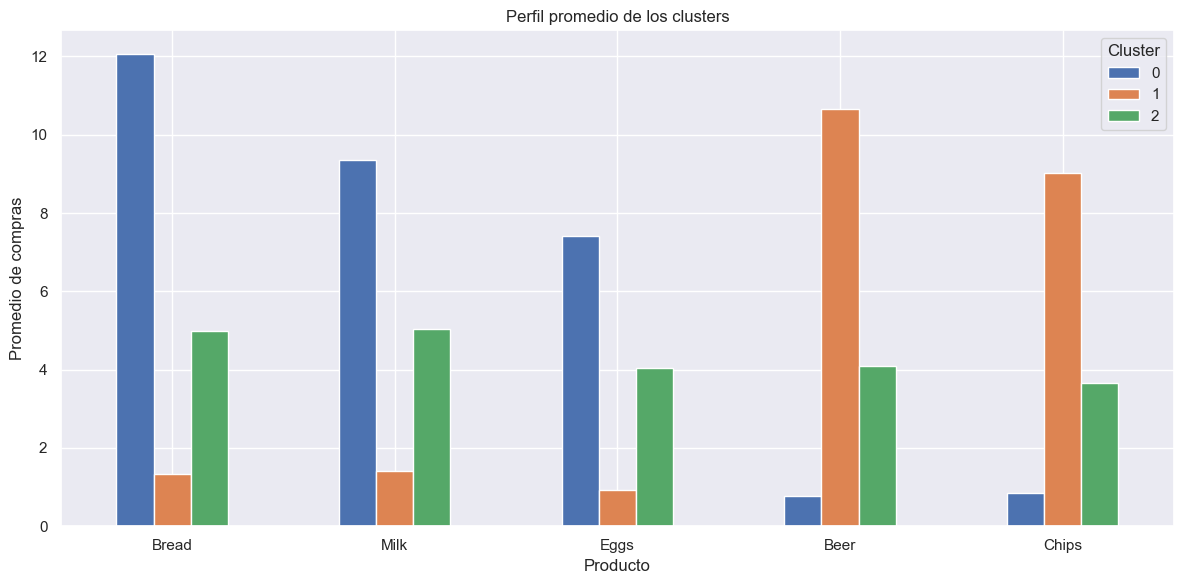

In [10]:
plt.figure(figsize=(12, 6))

perfil_clusters.T.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Perfil promedio de los clusters')
plt.xlabel('Producto')
plt.ylabel('Promedio de compras')
plt.xticks(rotation=0)
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

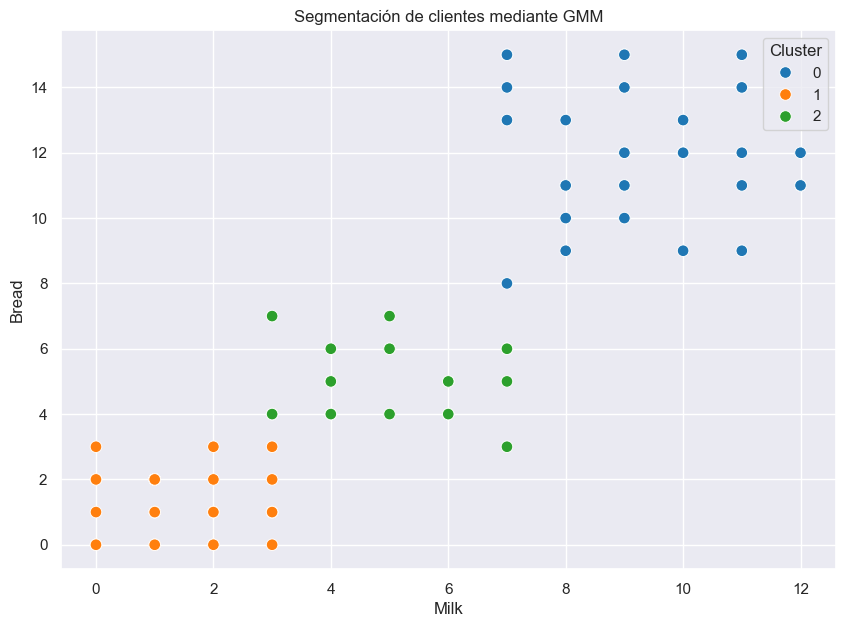

In [11]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Milk',
    y='Bread',
    hue='Cluster',
    palette='tab10',
    s=70
)

plt.title('Segmentación de clientes mediante GMM')
plt.xlabel('Milk')
plt.ylabel('Bread')
plt.legend(title='Cluster')

plt.show()

In [12]:
# Cree un nuevo cliente con la misma estructura del dataframe original
# Creamos un nuevo cliente
nuevo_cliente = pd.DataFrame({
    'Bread': [150],
    'Milk': [120],
    'Eggs': [80],
    'Beer': [60],
    'Chips': [90]
})

print("Nuevo cliente:")
display(nuevo_cliente)

Nuevo cliente:


,Bread,Milk,Eggs,Beer,Chips
0,150,120,80,60,90


In [13]:
# Prediga el cluster al que pertenece este nuevo cliente
# Escalamos el nuevo cliente utilizando
# el mismo scaler utilizado durante el entrenamiento
nuevo_cliente_scaled = scaler_customer.transform(
    nuevo_cliente[features_customer]
)

# Predicción del cluster
cluster_nuevo_cliente = gmm_customer.predict(
    nuevo_cliente_scaled
)[0]

# Probabilidades de pertenencia a cada cluster
probabilidades = gmm_customer.predict_proba(
    nuevo_cliente_scaled
)[0]

print(
    "El nuevo cliente pertenece al Cluster:",
    cluster_nuevo_cliente
)

print("\nProbabilidad de pertenencia a cada cluster:")

for cluster, prob in enumerate(probabilidades):
    print(
        f"Cluster {cluster}: {prob:.4f}"
    )


El nuevo cliente pertenece al Cluster: 0

Probabilidad de pertenencia a cada cluster:
Cluster 0: 1.0000
Cluster 1: 0.0000
Cluster 2: 0.0000


In [14]:
# En función al resultado, cree una recomendación a este nuevo cliente
# Calculamos el perfil de cada cluster
perfil = df.groupby('Cluster')[features_customer].mean()

# Obtenemos el perfil del cluster predicho
perfil_cliente = perfil.loc[cluster_nuevo_cliente]

print("Perfil del cluster del nuevo cliente:")
display(perfil_cliente.to_frame(name='Promedio'))
# Identificamos los productos con mayor consumo
productos_ordenados = (
    perfil_cliente
    .sort_values(ascending=False)
)

producto_principal = productos_ordenados.index[0]
producto_secundario = productos_ordenados.index[1]

print(f"El cliente pertenece al Cluster {cluster_nuevo_cliente}.")

print(f"Los productos más representativos de este segmento "    f"son {producto_principal} y {producto_secundario}.")

print("\nRECOMENDACIÓN:")

print(
    f"Ofrecer una promoción relacionada con "
    f"{producto_principal} y {producto_secundario}, "
    f"acompañada de productos complementarios.")

Perfil del cluster del nuevo cliente:


,Promedio
Bread,12.06250
Milk,9.34375
Eggs,7.40625
Beer,0.78125
Chips,0.84375


El cliente pertenece al Cluster 0.
Los productos más representativos de este segmento son Bread y Milk.

RECOMENDACIÓN:
Ofrecer una promoción relacionada con Bread y Milk, acompañada de productos complementarios.


**2.-**  Obtenga un modelo de clustering para el dataset `healthcare_dataset.csv` para obtener una agrupación de pacientes sanitarios mediante GMM: Los hospitales a menudo necesitan agrupar a pacientes con características similares para: identificar pacientes de alto riesgo, personalizar planes de tratamiento, optimizar la asignación de recursos y mejorar la gestión sanitaria.

In [20]:
#Cargamos el dataset
healthcare = pd.read_csv('./data/healthcare_dataset.csv')


In [27]:
#DIMENSIONES
 
print(
    "Dimensiones del dataset:",
    healthcare.shape
)

Dimensiones del dataset: (55500, 15)


In [25]:
#PRIMERAS FILAS
display(healthcare.head())

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [28]:
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [33]:
# Escalamiento y selección de características (¿Qué hacemos si tenemos colunas categoricas y numéricas y queremos utilizarlas en el clustering?
# Identificamos variables numéricas y categóricas
numeric_columns = healthcare.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = healthcare.select_dtypes(
    exclude=np.number
).columns.tolist()
#VARIABLES NUMERICAS
print("Variables numéricas:")
numeric_columns
#variables categoricas
print("\nVariables categóricas:")
categorical_columns

Variables numéricas:

Variables categóricas:


['Name',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results']

In [34]:
# Copiamos el dataset
healthcare_model = healthcare.copy()

# Eliminamos columnas identificadoras si existen
columns_to_drop = [
    'Name',
    'Patient ID',
    'Doctor',
    'Hospital',
    'Room Number',
    'Date of Admission',
    'Discharge Date'
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in healthcare_model.columns
]

healthcare_model = healthcare_model.drop(
    columns=columns_to_drop
)

print("Columnas eliminadas:")
print(columns_to_drop)

print("\nColumnas restantes:")
print(healthcare_model.columns.tolist())

Columnas eliminadas:
['Name', 'Doctor', 'Hospital', 'Room Number', 'Date of Admission', 'Discharge Date']

Columnas restantes:
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication', 'Test Results']


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Detectamos nuevamente los tipos de variables
numeric_features = healthcare_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = healthcare_model.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Variables numéricas:")
numeric_features

print("\nVariables categóricas:")
categorical_features

Variables numéricas:

Variables categóricas:


['Gender',
 'Blood Type',
 'Medical Condition',
 'Insurance Provider',
 'Admission Type',
 'Medication',
 'Test Results']

In [37]:
# Entrene el modelo por GMM utilice métricas para saber cuantos componentes elegir y cree una coluna para assignar el cluster
# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])

# Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False)
        )])

# Preprocesador
preprocessor = ColumnTransformer(transformers=[('num',numeric_transformer,numeric_features),('cat',categorical_transformer,categorical_features)])

# Transformamos los datos
X_healthcare = preprocessor.fit_transform(healthcare_model)

print("Dimensiones de los datos transformados:",X_healthcare.shape)

Dimensiones de los datos transformados: (55500, 34)


In [46]:
componentes_healthcare = range(2, 11)

# Reiniciar listas
aic_healthcare = []
bic_healthcare = []
silhouette_healthcare = []


In [47]:
max_muestra = 2000

if X_healthcare.shape[0] > max_muestra:

    rng = np.random.RandomState(42)

    indices_muestra = rng.choice(
        X_healthcare.shape[0],
        size=max_muestra,
        replace=False
    )

    X_silhouette = X_healthcare[indices_muestra]

else:

    X_silhouette = X_healthcare


print("Datos completos:", X_healthcare.shape)
print("Datos para Silhouette:", X_silhouette.shape)

Datos completos: (55500, 34)
Datos para Silhouette: (2000, 34)


In [48]:

for k in componentes_healthcare:

    print(f"Evaluando {k} componentes...")

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        random_state=42,
        n_init=3,
        max_iter=200
    )

    # Entrenar GMM con todos los datos
    gmm.fit(X_healthcare)

    # AIC y BIC
    aic = gmm.aic(X_healthcare)
    bic = gmm.bic(X_healthcare)

    # Predicciones únicamente sobre la muestra
    labels = gmm.predict(X_silhouette)

    # Silhouette sobre la muestra
    silhouette = silhouette_score(
        X_silhouette,
        labels
    )

    # Guardar resultados
    aic_healthcare.append(aic)
    bic_healthcare.append(bic)
    silhouette_healthcare.append(silhouette)


Evaluando 2 componentes...
Evaluando 3 componentes...
Evaluando 4 componentes...
Evaluando 5 componentes...
Evaluando 6 componentes...
Evaluando 7 componentes...
Evaluando 8 componentes...
Evaluando 9 componentes...
Evaluando 10 componentes...


In [49]:
print("\nVerificación de resultados:")
print("Componentes:", len(list(componentes_healthcare)))
print("AIC:", len(aic_healthcare))
print("BIC:", len(bic_healthcare))
print("Silhouette:", len(silhouette_healthcare))


Verificación de resultados:
Componentes: 9
AIC: 9
BIC: 9
Silhouette: 9


In [50]:
#graficas
metricas_healthcare = pd.DataFrame({
    'Componentes': list(componentes_healthcare),
    'AIC': aic_healthcare,
    'BIC': bic_healthcare,
    'Silhouette': silhouette_healthcare
})

display(
    metricas_healthcare.round(4)
)

,Componentes,AIC,BIC,Silhouette
0,2,2.035035e+06,2.036258e+06,0.0918
1,3,-1.231813e+06,-1.229974e+06,0.0260
2,4,-1.944677e+06,-1.942222e+06,0.0195
3,5,6.055954e+05,6.086653e+05,-0.0363
4,6,-2.017897e+06,-2.014212e+06,0.0177
5,7,-1.657405e+06,-1.653104e+06,0.0097
6,8,-3.132266e+06,-3.127348e+06,0.0240
7,9,-3.202835e+06,-3.197302e+06,0.0208
8,10,-2.915882e+06,-2.909733e+06,0.0201


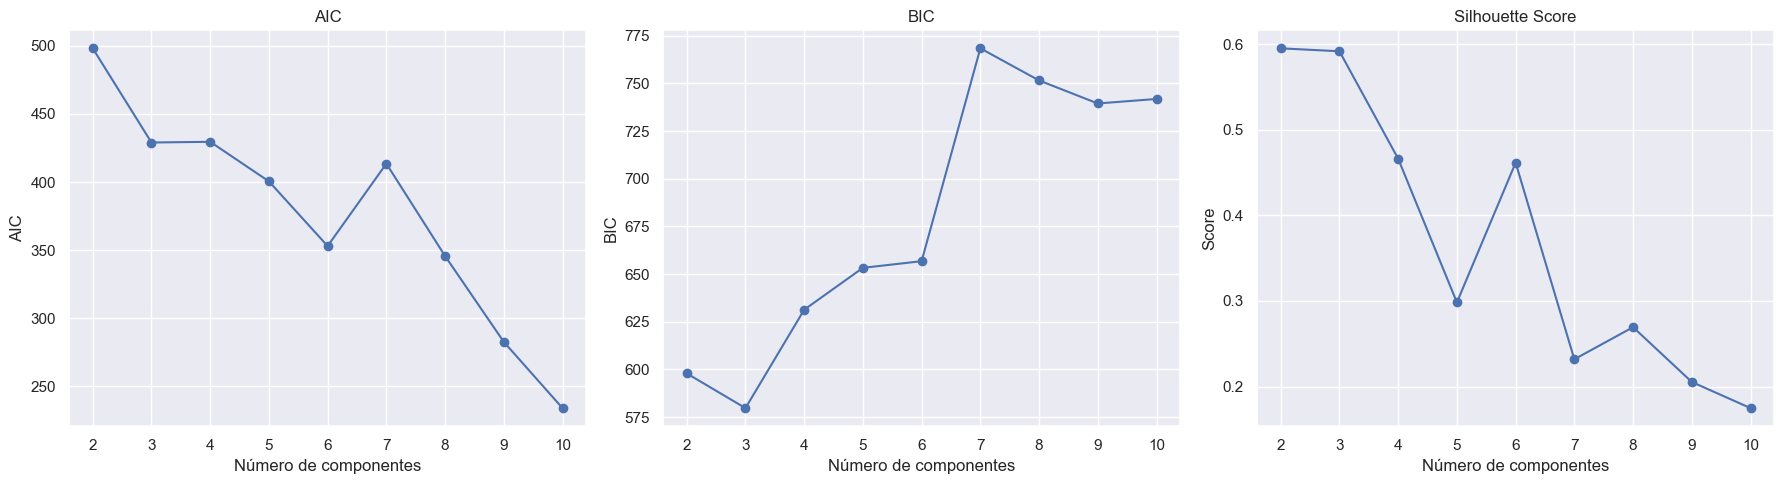

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AIC
axes[0].plot(
    metricas_customer['Componentes'],
    metricas_customer['AIC'],
    marker='o'
)

axes[0].set_title('AIC')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('AIC')
axes[0].grid(True)

# BIC
axes[1].plot(
    metricas_customer['Componentes'],
    metricas_customer['BIC'],
    marker='o'
)

axes[1].set_title('BIC')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('BIC')
axes[1].grid(True)

# Silhouette
axes[2].plot(
    metricas_customer['Componentes'],
    metricas_customer['Silhouette'],
    marker='o'
)

axes[2].set_title('Silhouette Score')
axes[2].set_xlabel('Número de componentes')
axes[2].set_ylabel('Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [52]:
# Seleccionamos el modelo con menor BIC
best_index_healthcare = (
    metricas_healthcare['BIC'].idxmin()
)

n_componentes_healthcare = int(
    metricas_healthcare.loc[
        best_index_healthcare,
        'Componentes'
    ]
)

print(
    "Número de componentes seleccionado:",
    n_componentes_healthcare
)

print(
    "AIC:",
    metricas_healthcare.loc[
        best_index_healthcare,
        'AIC'
    ]
)

print(
    "BIC:",
    metricas_healthcare.loc[
        best_index_healthcare,
        'BIC'
    ]
)

print(
    "Silhouette:",
    metricas_healthcare.loc[
        best_index_healthcare,
        'Silhouette'
    ]
)

Número de componentes seleccionado: 9
AIC: -3202834.9744826313
BIC: -3197302.0087367957
Silhouette: 0.020759085304420822


In [53]:
# Seleccionamos el modelo con menor BIC
best_index_healthcare = (
    metricas_healthcare['BIC'].idxmin()
)

n_componentes_healthcare = int(
    metricas_healthcare.loc[
        best_index_healthcare,
        'Componentes'
    ]
)

print(
    "Número de componentes seleccionado:",
    n_componentes_healthcare
)

print(
    "AIC:",
    metricas_healthcare.loc[
        best_index_healthcare,
        'AIC'
    ]
)

print(
    "BIC:",
    metricas_healthcare.loc[
        best_index_healthcare,
        'BIC'
    ]
)

print(
    "Silhouette:",
    metricas_healthcare.loc[
        best_index_healthcare,
        'Silhouette'
    ]
)

Número de componentes seleccionado: 9
AIC: -3202834.9744826313
BIC: -3197302.0087367957
Silhouette: 0.020759085304420822


In [55]:
# Modelo GMM definitivo
gmm_healthcare = GaussianMixture(
    n_components=n_componentes_healthcare,
    covariance_type='diag',
    random_state=42,
    n_init=10
)

# Predicción
healthcare_clusters = gmm_healthcare.fit_predict(
    X_healthcare
)

# Agregamos el cluster al dataset original
healthcare['Cluster'] = healthcare_clusters

print("Modelo GMM entrenado correctamente.")

print("\nNúmero de pacientes por cluster:")
print(
    healthcare['Cluster']
    .value_counts()
    .sort_index()
)

Modelo GMM entrenado correctamente.

Número de pacientes por cluster:
Cluster
0     3392
1     4651
2    11460
3     2322
4     4547
5     4746
6     5583
7     8430
8    10369
Name: count, dtype: int64


In [56]:

# Variables numéricas disponibles en el dataset original
numeric_original = healthcare.select_dtypes(
    include=np.number
).columns.tolist()

# Quitamos Cluster del cálculo
numeric_original = [
    col for col in numeric_original
    if col != 'Cluster'
]

# Perfil numérico por cluster
perfil_healthcare = healthcare.groupby(
    'Cluster'
)[numeric_original].mean()

print("Perfil promedio de pacientes por cluster:")
display(
    perfil_healthcare.round(2)
)

Perfil promedio de pacientes por cluster:


,Age,Billing Amount,Room Number
Cluster,,,
0,51.33,25344.18,300.15
1,51.63,25917.58,299.95
2,51.44,25349.93,303.52
3,51.92,25364.20,297.52
4,51.70,25283.31,304.12
5,51.57,25555.74,299.72
6,51.39,25698.95,300.30
7,51.74,25364.40,298.85
8,51.42,25843.01,301.81


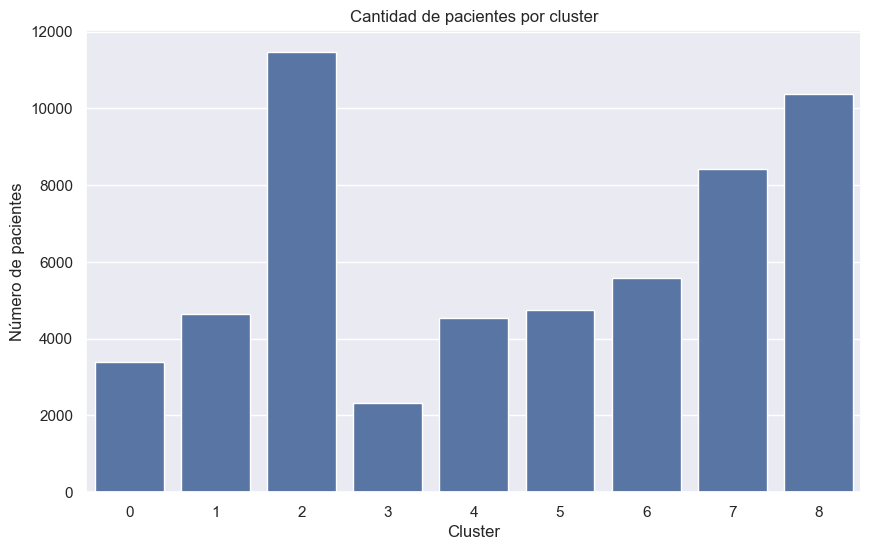

In [57]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=healthcare,
    x='Cluster'
)

plt.title(
    'Cantidad de pacientes por cluster'
)

plt.xlabel('Cluster')
plt.ylabel('Número de pacientes')

plt.show()

In [58]:
print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['Age', 'Billing Amount']

Variables categóricas:
['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication', 'Test Results']


In [62]:
nuevo_paciente = {}

# Valores de ejemplo para variables numéricas
for columna in numeric_features:
    
    if columna.lower() == 'age':
        nuevo_paciente[columna] = 45
        
    elif columna.lower() == 'billing amount':
        nuevo_paciente[columna] = 50000
        
    else:
        # Utilizamos la mediana de la variable
        nuevo_paciente[columna] = (
            healthcare_model[columna]
            .median()
        )

# Valores de ejemplo para variables categóricas
for columna in categorical_features:
    
    # Utilizamos la categoría más frecuente
    nuevo_paciente[columna] = (
        healthcare_model[columna]
        .mode()[0]
    )

nuevo_paciente = pd.DataFrame(
    [nuevo_paciente]
)

print("Nuevo paciente:")
display(nuevo_paciente)

Nuevo paciente:


,Age,Billing Amount,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results
0,45,50000,Male,A-,Arthritis,Cigna,Elective,Lipitor,Abnormal


In [63]:
# Transformamos el nuevo paciente
nuevo_paciente_transformado = preprocessor.transform(
    nuevo_paciente
)

# Predicción del cluster
cluster_nuevo_paciente = (
    gmm_healthcare
    .predict(nuevo_paciente_transformado)[0]
)

# Probabilidades
probabilidades_paciente = (
    gmm_healthcare
    .predict_proba(nuevo_paciente_transformado)[0]
)

print(
    "El nuevo paciente pertenece al Cluster:",
    cluster_nuevo_paciente
)

print("\nProbabilidad de pertenencia:")

for cluster, prob in enumerate(
    probabilidades_paciente
):
    print(
        f"Cluster {cluster}: {prob:.4f}"
    )

El nuevo paciente pertenece al Cluster: 8

Probabilidad de pertenencia:
Cluster 0: 0.0000
Cluster 1: 0.0000
Cluster 2: 0.0000
Cluster 3: 0.0000
Cluster 4: 0.0000
Cluster 5: 0.0000
Cluster 6: 0.0000
Cluster 7: 0.0000
Cluster 8: 1.0000


In [64]:
print(
    f"El nuevo paciente fue asignado al "
    f"Cluster {cluster_nuevo_paciente}."
)

print(
    "\nCantidad de pacientes en este cluster:"
)

cantidad = (
    healthcare['Cluster']
    .value_counts()
    .loc[cluster_nuevo_paciente]
)

print(cantidad)

El nuevo paciente fue asignado al Cluster 8.

Cantidad de pacientes en este cluster:
10369


In [65]:
print(
    f"Perfil numérico del Cluster "
    f"{cluster_nuevo_paciente}:"
)

display(
    perfil_healthcare
    .loc[cluster_nuevo_paciente]
    .to_frame(
        name='Promedio'
    )
)

Perfil numérico del Cluster 8:


,Promedio
Age,51.423763
Billing Amount,25843.006825
Room Number,301.814158


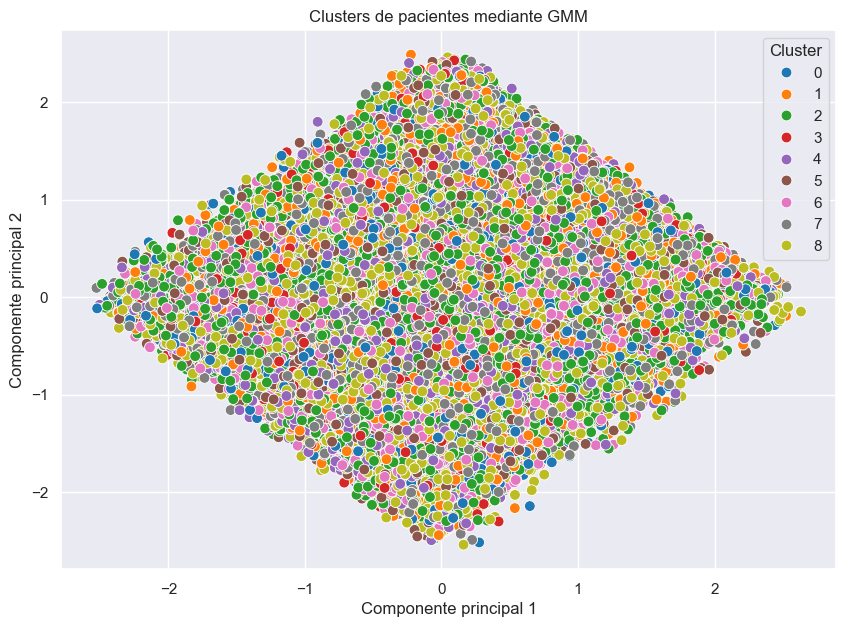

In [66]:
from sklearn.decomposition import PCA

# Reducimos a dos dimensiones
pca = PCA(
    n_components=2,
    random_state=42
)

X_healthcare_pca = pca.fit_transform(
    X_healthcare
)

# DataFrame para visualizar
pca_df = pd.DataFrame({
    'PCA1': X_healthcare_pca[:, 0],
    'PCA2': X_healthcare_pca[:, 1],
    'Cluster': healthcare_clusters
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='tab10',
    s=60
)

plt.title(
    'Clusters de pacientes mediante GMM'
)

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')

plt.legend(title='Cluster')

plt.show()

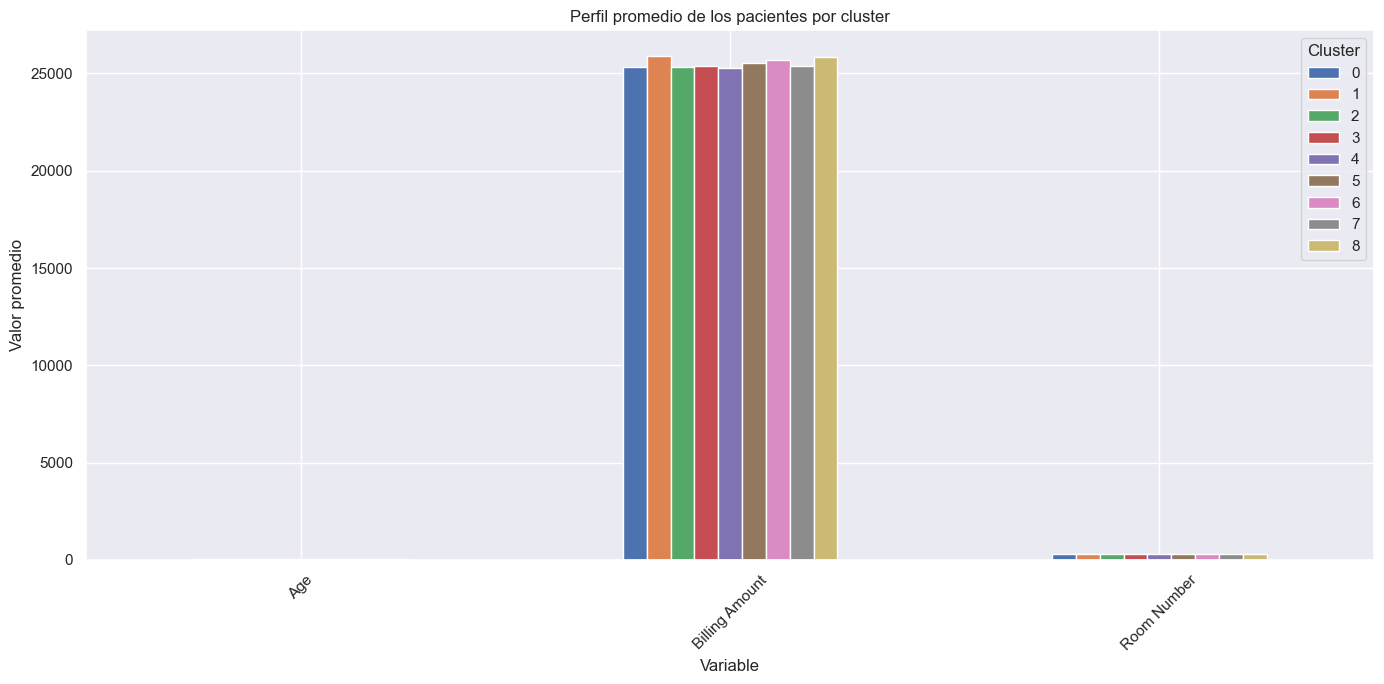

In [67]:
# Seleccionamos únicamente variables numéricas
if len(numeric_original) > 0:

    perfil_healthcare.T.plot(
        kind='bar',
        figsize=(14, 7)
    )

    plt.title(
        'Perfil promedio de los pacientes por cluster'
    )

    plt.xlabel('Variable')
    plt.ylabel('Valor promedio')

    plt.xticks(rotation=45)

    plt.legend(
        title='Cluster'
    )

    plt.tight_layout()
    plt.show()

In [69]:
print("=" * 60)
print("RESUMEN DE LA ACTIVIDAD")
print("=" * 60)

print("\n1. SEGMENTACIÓN DE CLIENTES")
print("-" * 60)

print(
    f"Número de clusters seleccionados: "
    f"{n_componentes_customer}"
)

print(
    f"Silhouette Score: "
    f"{metricas_customer.loc[best_index, 'Silhouette']:.4f}"
)

print(
    f"Nuevo cliente -> Cluster "
    f"{cluster_nuevo_cliente}"
)

print("\n2. SEGMENTACIÓN DE PACIENTES")
print("-" * 60)

print(
    f"Número de clusters seleccionados: "
    f"{n_componentes_healthcare}"
)

print(
    f"Silhouette Score: "
    f"{metricas_healthcare.loc[best_index_healthcare, 'Silhouette']:.4f}"
)

print(
    f"Nuevo paciente -> Cluster "
    f"{cluster_nuevo_paciente}"
)

RESUMEN DE LA ACTIVIDAD

1. SEGMENTACIÓN DE CLIENTES
------------------------------------------------------------
Número de clusters seleccionados: 3
Silhouette Score: 0.5916
Nuevo cliente -> Cluster 0

2. SEGMENTACIÓN DE PACIENTES
------------------------------------------------------------
Número de clusters seleccionados: 9
Silhouette Score: 0.0208
Nuevo paciente -> Cluster 8
